In [8]:
import numpy as np
import pandas as pd

# load data
df = pd.read_csv("three_noisy_signals.csv")

# time
t = df["time"].values

# true global temperature = original sine wave
df["global_temperature"] = np.sin(2 * np.pi * 0.5 * t)

# input: noisy local sensors
X_raw = df[["signal2_noisy", "signal3_noisy", "signal4_noisy"]].values

# mask: 1 = observed, 0 = missing
mask = (~np.isnan(X_raw)).astype(float)

# fill missing values with column means
col_means = np.nanmean(X_raw, axis=0)
X_filled = np.where(np.isnan(X_raw), col_means, X_raw)

# add mask channels
X_model = np.concatenate([X_filled, mask], axis=1)

# target
y_raw = df["global_temperature"].values

# reshape
X = X_model[np.newaxis, :, :]          # (1, 200, 6)
y = y_raw[np.newaxis, :, np.newaxis]   # (1, 200, 1)

# normalize
X_mean = X.mean()
X_std = X.std()

y_mean = y.mean()
y_std = y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

print(np.isnan(X_norm).sum())
print(np.isnan(y_norm).sum())
print(X_norm.shape, y_norm.shape)

0
0
(1, 200, 6) (1, 200, 1)


In [9]:
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

inputs = Input(shape=(X_norm.shape[1], X_norm.shape[2]))

lstm_out = LSTM(64, return_sequences=True)(inputs)

attn_out = Attention()([lstm_out, lstm_out])

x = Concatenate()([lstm_out, attn_out])

outputs = Dense(1)(x)

attention_model = Model(inputs, outputs)

attention_model.compile(
    optimizer="adam",
    loss="mse"
)

attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 200, 64)   │     18,176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 200, 64)   │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 200, 128)  │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 200, 1)    │        129 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,305 (71.50 KB)

 Trainable params: 18,305 (71.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_attn = attention_model.fit(
    X_norm,
    y_norm,
    epochs=200,
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.0122
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.9814
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.9527
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.9254
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.8993
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.8739
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.8490
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.8241
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.7990
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.7734
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.7469
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.7192
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.6901
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.6592
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.6260
Epoch 16/200
1/1 ━

In [11]:
y_pred_attn_norm = attention_model.predict(X_norm)
y_pred_attn = y_pred_attn_norm * y_std + y_mean

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


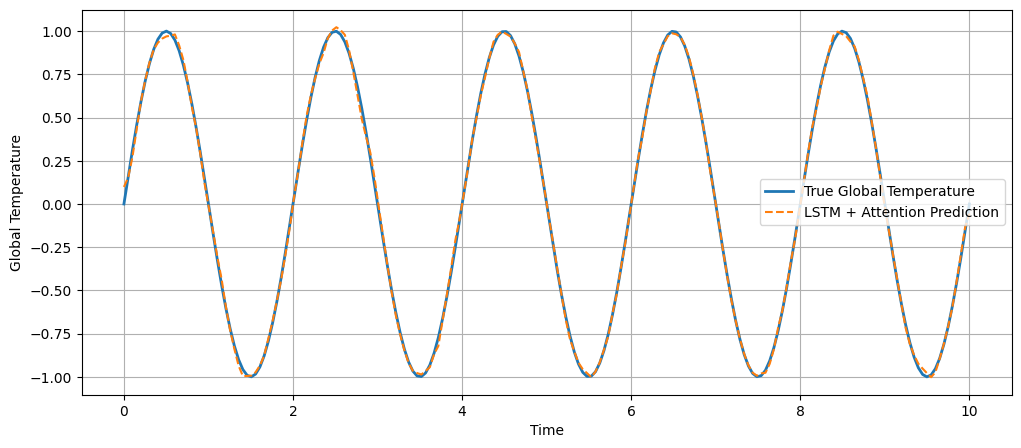

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(t, y[0, :, 0], label="True Global Temperature", linewidth=2)
plt.plot(t, y_pred_attn[0, :, 0], label="LSTM + Attention Prediction", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Global Temperature")
plt.legend()
plt.grid(True)
plt.show()